# 🛒 Olist E-Commerce Business Analysis
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Author:** [Your Name]  

---

## Project Overview

This project analyses real-world sales data from **Olist**, Brazil's largest e-commerce marketplace.  
The dataset covers **~100,000 orders** placed between 2016 and 2018 across multiple product categories.

### Objectives
- Understand sales trends and top-performing product categories
- Analyse delivery performance and its impact on customer satisfaction
- Identify peak shopping times and customer behaviour patterns
- Generate actionable business insights from raw data

### Dataset Tables Used
| Table | Description |
|-------|-------------|
| orders | Order status and timestamps |
| customers | Customer location info |
| order_items | Products and prices per order |
| payments | Payment method and value |
| reviews | Customer review scores |
| products | Product category info |
| sellers | Seller location info |

---

## Workflow
1. **Data Loading** — Load all 8 CSV files
2. **Data Cleaning** — Handle nulls, fix data types, standardise text
3. **Feature Engineering** — Build master table, add delivery & time features
4. **Exploratory Data Analysis** — Answer 6 key business questions with charts
5. **Business Insights** — Summarise findings

---

## Phase 1 — Setup & Data Loading

In [1]:
pip install pandas matplotlib numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sc

In [3]:
customers=pd.read_csv("C:\P1_DS\olist_customers_dataset.csv")
location=pd.read_csv("C:\P1_DS\olist_geolocation_dataset.csv")
items=pd.read_csv("C:\P1_DS\olist_order_items_dataset.csv")
payments=pd.read_csv("C:\P1_DS\olist_order_payments_dataset.csv")
reviews=pd.read_csv("C:\P1_DS\olist_order_reviews_dataset.csv")
orders=pd.read_csv("C:\P1_DS\olist_orders_dataset.csv")
products=pd.read_csv("C:\P1_DS\olist_products_dataset.csv")
sellers=pd.read_csv("C:\P1_DS\olist_sellers_dataset.csv")
pro_cat=pd.read_csv("C:\P1_DS\product_category_name_translation.csv")

In [4]:
# storing all datasets in a single dictionary
datasets = {
    'orders': orders,
    'customers': customers,
    'payments': payments,
    'items': items,
    'products': products,
    'pro_cat'  : pro_cat,
    'sellers'  : sellers,
    'reviews'  : reviews
}

In [5]:
#printing the info about the datasets
for name,df in datasets.items():
    print(f"\n {"=="*50}")
    print(f"    \n{name.upper()}")
    print(f"shape:{df.shape}")
    print(f"dtypes:{df.dtypes}")
    nulls=df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls)>0:
        print(f"  Nulls:  ")
        print(nulls)
    else:
        print("Nulls are none , clean dataset")


    
ORDERS
shape:(99441, 8)
dtypes:order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
  Nulls:  
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

    
CUSTOMERS
shape:(99441, 5)
dtypes:customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
Nulls are none , clean dataset

    
PAYMENTS
shape:(103886, 5)
dtypes:order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
Nulls are none , 

In [6]:
#column checker

def col_profile(df,name):
     print(f"\n FULL COLUMN PROFILE — {name.upper()} \n")
     for col in df.columns:
        null_count =  df[col].isnull().sum()
        null_pct   =  round(null_count / len(df) * 100, 1)
        unique     =  df[col].nunique()
        dtype      =  df[col].dtype
        samples     =  df[col].dropna().head(3).tolist()
        print(f"  Column  : {col}")
        print(f"  Type    : {dtype}")
        print(f"  Nulls   : {null_count} ({null_pct}%)")
        print(f"  Unique  : {unique}")
        print(f"  Samples : {samples}")
        print(f"  {'-'*40}")

#running on all datasets
col_profile(orders,'orders')
col_profile(customers, 'customers')
col_profile(payments, 'payments')
col_profile(items, 'items')
col_profile(products, 'products')
col_profile(pro_cat,'pro_cat')  
col_profile(sellers,'sellers')
col_profile(reviews,'reviews')


 FULL COLUMN PROFILE — ORDERS 

  Column  : order_id
  Type    : object
  Nulls   : 0 (0.0%)
  Unique  : 99441
  Samples : ['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d']
  ----------------------------------------
  Column  : customer_id
  Type    : object
  Nulls   : 0 (0.0%)
  Unique  : 99441
  Samples : ['9ef432eb6251297304e76186b10a928d', 'b0830fb4747a6c6d20dea0b8c802d7ef', '41ce2a54c0b03bf3443c3d931a367089']
  ----------------------------------------
  Column  : order_status
  Type    : object
  Nulls   : 0 (0.0%)
  Unique  : 8
  Samples : ['delivered', 'delivered', 'delivered']
  ----------------------------------------
  Column  : order_purchase_timestamp
  Type    : object
  Nulls   : 0 (0.0%)
  Unique  : 98875
  Samples : ['2017-10-02 10:56:33', '2018-07-24 20:41:37', '2018-08-08 08:38:49']
  ----------------------------------------
  Column  : order_approved_at
  Type    : object
  Nulls   : 160 (0.2%)
  Unique  : 

## Phase 2 — Data Cleaning

Each dataset is cleaned individually before being merged into a master table.

In [7]:
#cleaning of orders dataset
orders_clean=orders.copy()
#drop the rows where key column is missing 
orders_clean.dropna(subset=['order_id', 'customer_id'], inplace=True)

#converting date columns from text to date format
dates_col= ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in dates_col:
    orders_clean[col]=pd.to_datetime(orders_clean[col], errors='coerce')




In [8]:
#Cleaning customers dataset
customers_clean=customers.copy()
customers['customer_city'].unique()[1:30]
#Coverting lower case city names to title case
customers_clean['customer_city'] = (customers_clean['customer_city'].str.strip().str.title())
print(f"{customers_clean["customer_city"]}")
# Zip code is int64 — convert to string
customers_clean['customer_zip_code_prefix'] = (
    customers_clean['customer_zip_code_prefix']
    .astype(str)
)
print("Customers clean shape:", customers_clean.shape)
print(customers_clean['customer_city'].head(5))


0                       Franca
1        Sao Bernardo Do Campo
2                    Sao Paulo
3              Mogi Das Cruzes
4                     Campinas
                 ...          
99436                Sao Paulo
99437          Taboao Da Serra
99438                Fortaleza
99439                   Canoas
99440                    Cotia
Name: customer_city, Length: 99441, dtype: object
Customers clean shape: (99441, 5)
0                   Franca
1    Sao Bernardo Do Campo
2                Sao Paulo
3          Mogi Das Cruzes
4                 Campinas
Name: customer_city, dtype: object


In [9]:
#cleaning payments dataset
payments_clean= datasets["payments"].copy()

#Removing the null values from the key column
payments_clean.dropna(subset=['order_id'], inplace=True)

# Remove zero value payments
payments_clean=payments_clean[payments_clean['payment_value']>0]

# 'sum'   → add all payments for this order together
# 'first' → take the first payment method (main method)
# 'max'   → highest instalment number used
# 'count' → how many payment rows existed for this order
# .reset_index() → moves order_id back as a regular column

payments_agg=payments_clean.groupby('order_id').agg(
     total_payment        = ('payment_value',       'sum'),
    payment_type         = ('payment_type',         'first'),
    payment_installments = ('payment_installments', 'max'),
    payment_count        = ('payment_sequential',   'count')
).reset_index()
print(f"Rows before: {len(payments_clean)}")
print(f"Rows after : {len(payments_agg)}")
# Rows should drop — that means duplicates were collapsed successfully

Rows before: 103877
Rows after : 99437


In [10]:
#cleaning items table

items_clean=datasets['items'].copy()
items_clean.dropna(subset=['order_id', 'product_id'], inplace=True)

items_clean = items_clean[items_clean['price'] > 0]

# Fill null freight values with 0 — null here means free shipping
items_clean['freight_value'].fillna(0, inplace=True)

items_agg = items_clean.groupby('order_id').agg(
    item_count        = ('order_item_id', 'count'),
    total_items_value = ('price',         'sum'),
    avg_item_price    = ('price',         'mean'),
    total_freight     = ('freight_value', 'sum'),
    product_id        = ('product_id',    'first'),
    seller_id         = ('seller_id',     'first')
).reset_index()

print(f"Rows before: {len(items_clean)}")
print(f"Rows after : {len(items_agg)}")
print(items_agg.head())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20364\2822877941.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  items_clean['freight_value'].fillna(0, inplace=True)


Rows before: 112650
Rows after : 98666
                           order_id  item_count  total_items_value  \
0  00010242fe8c5a6d1ba2dd792cb16214           1              58.90   
1  00018f77f2f0320c557190d7a144bdd3           1             239.90   
2  000229ec398224ef6ca0657da4fc703e           1             199.00   
3  00024acbcdf0a6daa1e931b038114c75           1              12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9           1             199.90   

   avg_item_price  total_freight                        product_id  \
0           58.90          13.29  4244733e06e7ecb4970a6e2683c13e61   
1          239.90          19.93  e5f2d52b802189ee658865ca93d83a8f   
2          199.00          17.87  c777355d18b72b67abbeef9df44fd0fd   
3           12.99          12.79  7634da152a4610f1595efa32f14722fc   
4          199.90          18.14  ac6c3623068f30de03045865e4e10089   

                          seller_id  
0  48436dade18ac8b2bce089ec2a041202  
1  dd7ddc04e1b6c2c614352b383efe2d36  
2  5b

In [11]:
products_clean = products.copy()

# Fill missing category with 'unknown'
products_clean['product_category_name'].fillna('unknown', inplace=True)

# Fill the 2 missing weight/dimension rows with median
for col in ['product_weight_g','product_length_cm',
            'product_height_cm','product_width_cm']:
    products_clean[col].fillna(products_clean[col].median(), inplace=True)

# Merge with translation table to get English category names
products_clean = products_clean.merge(pro_cat, on='product_category_name', how='left')

# Fill any categories that didn't get translated
products_clean['product_category_name_english'].fillna('unknown', inplace=True)

# Keep only useful columns
products_clean = products_clean[[
    'product_id',
    'product_category_name_english',
    'product_weight_g'
]]

print("Products clean shape:", products_clean.shape)
print(products_clean['product_category_name_english'].value_counts().head(10))


Products clean shape: (32951, 3)
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20364\3863779120.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_clean['product_category_name'].fillna('unknown', inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20364\3863779120.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [12]:
reviews_clean = reviews.copy()

# review_comment_title has 88% nulls — useless, drop it
# review_comment_message has 58% nulls — drop it too
# We only need order_id and review_score
reviews_clean = reviews_clean[['order_id', 'review_score']]

# One order can have multiple reviews — keep the latest one
reviews_clean = reviews_clean.groupby('order_id').agg(
    review_score = ('review_score', 'mean')
).reset_index()

reviews_clean['review_score'] = reviews_clean['review_score'].round(1)

print("Reviews clean shape:", reviews_clean.shape)
print(reviews_clean.head(3))

Reviews clean shape: (98673, 2)
                           order_id  review_score
0  00010242fe8c5a6d1ba2dd792cb16214           5.0
1  00018f77f2f0320c557190d7a144bdd3           4.0
2  000229ec398224ef6ca0657da4fc703e           5.0


In [13]:
# Create a copy
sellers_clean = sellers.copy()

# Remove duplicates

sellers_clean = sellers_clean.drop_duplicates()

# Clean text columns
sellers_clean["seller_city"] = sellers_clean["seller_city"].str.strip().str.lower()
sellers_clean["seller_state"] = sellers_clean["seller_state"].str.strip().str.upper()
print(sellers_clean.head())

                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  


In [14]:
#Creating master table

master=orders_clean.copy()
print(f"Base orders:{master.shape}")

Base orders:(99441, 8)


In [15]:
#Merging the tables
master=master.merge(customers_clean , on='customer_id',how='left')
print(f"After customers: {master.shape}")



After customers: (99441, 12)


In [16]:
master = master.merge(payments_agg, on='order_id', how='left')
print(f"After payments  : {master.shape}")

After payments  : (99441, 16)


In [17]:
master = master.merge(items_agg, on='order_id', how='left')
print(f"After items :{master.shape}")

After items :(99441, 22)


In [18]:
master = master.merge(products_clean, on='product_id', how='left')
print(f"After products  : {master.shape}")

After products  : (99441, 24)


In [19]:
master = master.merge(reviews_clean, on='order_id', how='left')
print(f"After reviews   : {master.shape}")

After reviews   : (99441, 25)


In [20]:
master = master.merge(sellers_clean, on='seller_id', how='left')
print(f"After sellers   : {master.shape}")

After sellers   : (99441, 28)


In [21]:
# Save master to CSV — so you never run cleaning again
master.to_csv('olist_master.csv', index=False)

# Final summary
print("=== MASTER DATAFRAME READY ===")
print(f"Shape          : {master.shape}")
print(f"Columns        : {master.columns.tolist()}")
print(f"\nNull check     :")
print(master.isnull().sum()[master.isnull().sum() > 0])

=== MASTER DATAFRAME READY ===
Shape          : (99441, 28)
Columns        : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment', 'payment_type', 'payment_installments', 'payment_count', 'item_count', 'total_items_value', 'avg_item_price', 'total_freight', 'product_id', 'seller_id', 'product_category_name_english', 'product_weight_g', 'review_score', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Null check     :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
total_payment                       4
payment_type                        4
payment_installments                4
payment_count                       4
item_count                        775
total_items_value           

## Phase 3 — Feature Engineering

Building useful columns from the raw data for analysis.

In [22]:
# order_purchase_timestamp is a datetime column
# We pull useful pieces out of it for time-based analysis
# These answer questions like "which month had most orders?"
# "do people shop more on weekends?"

master['purchase_year']    = master['order_purchase_timestamp'].dt.year
master['purchase_month']   = master['order_purchase_timestamp'].dt.month
master['purchase_day']     = master['order_purchase_timestamp'].dt.day
master['purchase_weekday'] = master['order_purchase_timestamp'].dt.day_name()
master['purchase_hour']    = master['order_purchase_timestamp'].dt.hour
master['purchase_quarter'] = master['order_purchase_timestamp'].dt.quarter

print(master[['order_purchase_timestamp','purchase_year',
              'purchase_month','purchase_weekday',
              'purchase_hour','purchase_quarter']].head(5))

  order_purchase_timestamp  purchase_year  purchase_month purchase_weekday  \
0      2017-10-02 10:56:33           2017              10           Monday   
1      2018-07-24 20:41:37           2018               7          Tuesday   
2      2018-08-08 08:38:49           2018               8        Wednesday   
3      2017-11-18 19:28:06           2017              11         Saturday   
4      2018-02-13 21:18:39           2018               2          Tuesday   

   purchase_hour  purchase_quarter  
0             10                 4  
1             20                 3  
2              8                 3  
3             19                 4  
4             21                 1  


In [23]:
# How many days did delivery take?
# We subtract purchase date from delivery date
# This answers "how fast is Olist delivering?"
# For undelivered orders this will be NaN — that is expected

master['delivery_days'] = (
    master['order_delivered_customer_date']
    - master['order_purchase_timestamp']
).dt.days

print(master[['order_status','delivery_days']].head(10))
print(f"\nAverage delivery days: {master['delivery_days'].mean():.1f}")

  order_status  delivery_days
0    delivered            8.0
1    delivered           13.0
2    delivered            9.0
3    delivered           13.0
4    delivered            2.0
5    delivered           16.0
6     invoiced            NaN
7    delivered            9.0
8    delivered            9.0
9    delivered           18.0

Average delivery days: 12.1


In [24]:
# Did the order arrive before or after the estimated date?
# Positive number = arrived LATE
# Negative number = arrived EARLY
# This tells us how accurate Olist's delivery estimates are

master['delivery_delay_days'] = (
    master['order_delivered_customer_date']
    - master['order_estimated_delivery_date']
).dt.days

print(master[['delivery_days','delivery_delay_days']].describe())

       delivery_days  delivery_delay_days
count   96476.000000         96476.000000
mean       12.094086           -11.876881
std         9.551746            10.183854
min         0.000000          -147.000000
25%         6.000000           -17.000000
50%        10.000000           -12.000000
75%        15.000000            -7.000000
max       209.000000           188.000000


In [25]:
# Simple yes/no column — was this order delivered late?
# True  = arrived after estimated date (late)
# False = arrived on time or early
# This is very useful for analysis — "what % of orders are late?"
# and "do late deliveries get lower review scores?"

master['is_late'] = master['delivery_delay_days'] > 0

print(master['is_late'].value_counts())
print(f"\nLate delivery rate: {master['is_late'].mean()*100:.1f}%")

is_late
False    92906
True      6535
Name: count, dtype: int64

Late delivery rate: 6.6%


In [26]:
# total_items_value = cost of products
# total_freight     = shipping cost
# Together they = what customer actually paid
# We verify this against total_payment from payments table

master['order_value'] = master['total_items_value'] + master['total_freight']

# Check how close it is to total_payment
master['payment_difference'] = (
    master['total_payment'] - master['order_value']
).round(2)

print(master[['total_items_value','total_freight',
              'order_value','total_payment',
              'payment_difference']].head(5))


   total_items_value  total_freight  order_value  total_payment  \
0              29.99           8.72        38.71          38.71   
1             118.70          22.76       141.46         141.46   
2             159.90          19.22       179.12         179.12   
3              45.00          27.20        72.20          72.20   
4              19.90           8.72        28.62          28.62   

   payment_difference  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  


In [27]:
# Instead of raw numbers, group orders into buckets
# This makes charts and analysis much cleaner
# "Low value order" vs "High value order"

master['order_value_category'] = pd.cut(
    master['total_payment'],
    bins=[0, 50, 150, 300, 500, float('inf')],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

print(master['order_value_category'].value_counts())

order_value_category
Low          50125
Medium       22040
Very Low     16955
High          6021
Very High     4296
Name: count, dtype: int64


In [28]:
# Did the customer order on a weekend?
# 5 = Saturday, 6 = Sunday
# Useful for understanding shopping behaviour patterns

master['is_weekend'] = master['order_purchase_timestamp'].dt.dayofweek >= 5

print(master['is_weekend'].value_counts())
print(f"\nWeekend orders: {master['is_weekend'].mean()*100:.1f}%")

is_weekend
False    76594
True     22847
Name: count, dtype: int64

Weekend orders: 23.0%


In [29]:
print("=== AFTER FEATURE ENGINEERING ===")
print(f"Shape: {master.shape}")
print(f"\nNew columns added:")
new_cols = ['purchase_year','purchase_month','purchase_day',
            'purchase_weekday','purchase_hour','purchase_quarter',
            'delivery_days','delivery_delay_days','is_late',
            'order_value','payment_difference',
            'order_value_category','is_weekend']
print(new_cols)
print(f"\nSample:")
print(master[new_cols].head(5))

# Save updated master
master.to_csv('olist_master.csv', index=False)
print("\nMaster saved with new features!")

=== AFTER FEATURE ENGINEERING ===
Shape: (99441, 41)

New columns added:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_weekday', 'purchase_hour', 'purchase_quarter', 'delivery_days', 'delivery_delay_days', 'is_late', 'order_value', 'payment_difference', 'order_value_category', 'is_weekend']

Sample:
   purchase_year  purchase_month  purchase_day purchase_weekday  \
0           2017              10             2           Monday   
1           2018               7            24          Tuesday   
2           2018               8             8        Wednesday   
3           2017              11            18         Saturday   
4           2018               2            13          Tuesday   

   purchase_hour  purchase_quarter  delivery_days  delivery_delay_days  \
0             10                 4            8.0                 -8.0   
1             20                 3           13.0                 -6.0   
2              8                 3            9.0         

# Phase 3 — Exploratory Data Analysis

Simple questions, simple charts. Each cell does one thing.

In [30]:
# Load master if not already in memory
try:
    master
    print("master already in memory:", master.shape)
except NameError:
    master = pd.read_csv("olist_master.csv", parse_dates=["order_purchase_timestamp"])
    print("Loaded:", master.shape)

master already in memory: (99441, 41)


## Q1 — Which month had the most orders?

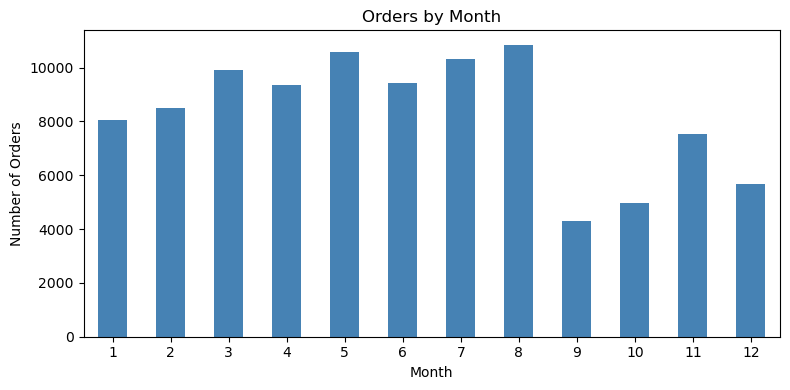

Best month: 8
Orders: 10843


In [31]:
monthly_orders = master.groupby("purchase_month").size()

monthly_orders.plot(kind="bar", figsize=(8, 4), color="steelblue")
plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Best month:", monthly_orders.idxmax())
print("Orders:", monthly_orders.max())

## Q2 — What are the top 5 product categories?

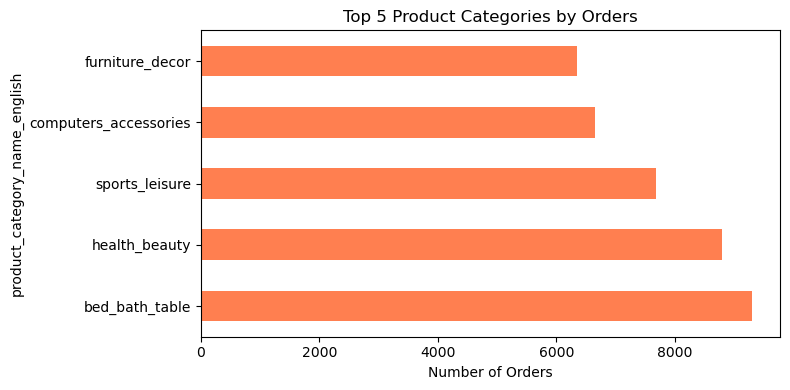

product_category_name_english
bed_bath_table           9311
health_beauty            8796
sports_leisure           7681
computers_accessories    6660
furniture_decor          6355
Name: order_id, dtype: int64


In [32]:
top_categories = (
    master.groupby("product_category_name_english")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(5)
)

top_categories.plot(kind="barh", figsize=(8, 4), color="coral")
plt.title("Top 5 Product Categories by Orders")
plt.xlabel("Number of Orders")
plt.tight_layout()
plt.show()

print(top_categories)

## Q3 — How do customers pay?

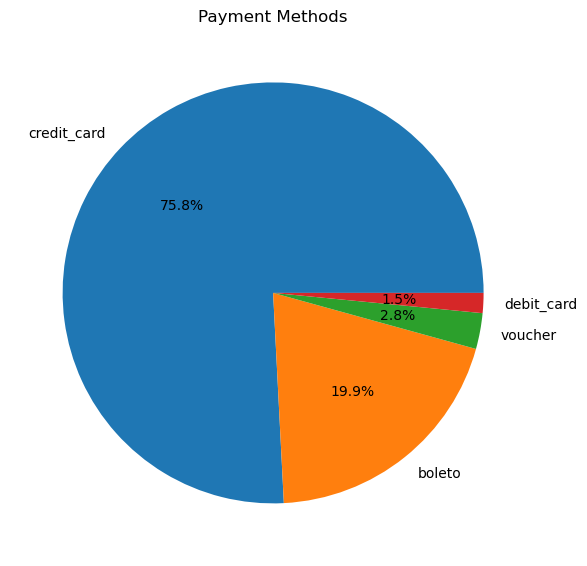

In [33]:
payment_counts = master["payment_type"].value_counts()

payment_counts.plot(kind="pie", figsize=(6, 6), autopct="%1.1f%%")
plt.title("Payment Methods")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Q4 — What percentage of orders are delivered late?

On time : 89,944
Late    : 6,534
Late %  : 6.8%


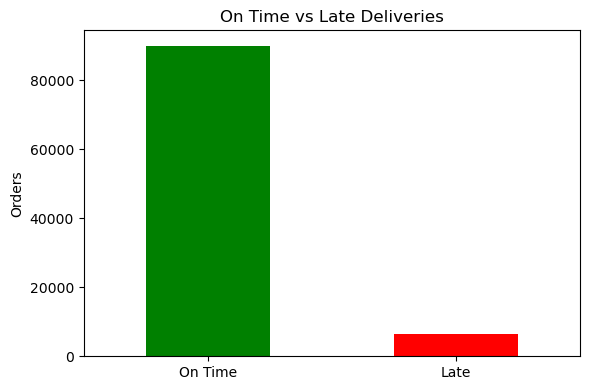

In [34]:
delivered = master[master["order_status"] == "delivered"]

late_count    = delivered["is_late"].sum()
on_time_count = (~delivered["is_late"]).sum()
late_pct      = delivered["is_late"].mean() * 100

print(f"On time : {on_time_count:,}")
print(f"Late    : {late_count:,}")
print(f"Late %  : {late_pct:.1f}%")

pd.Series({"On Time": on_time_count, "Late": late_count}).plot(
    kind="bar", color=["green", "red"], figsize=(6, 4)
)
plt.title("On Time vs Late Deliveries")
plt.ylabel("Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Q5 — Do late deliveries get lower review scores?

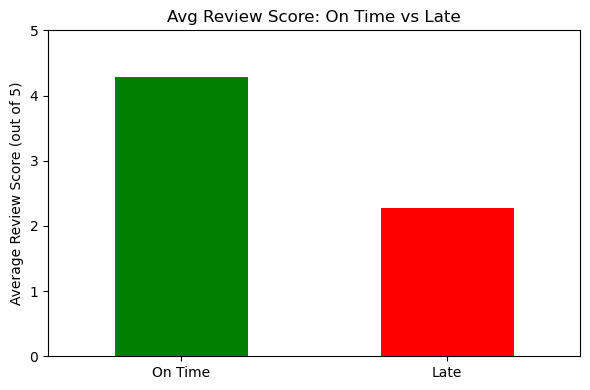

On Time    4.290607
Late       2.271823
Name: review_score, dtype: float64


In [35]:
avg_review = delivered.groupby("is_late")["review_score"].mean()
avg_review.index = ["On Time", "Late"]

avg_review.plot(kind="bar", color=["green", "red"], figsize=(6, 4))
plt.title("Avg Review Score: On Time vs Late")
plt.ylabel("Average Review Score (out of 5)")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

print(avg_review)

## Q6 — What hour of day do most people shop?

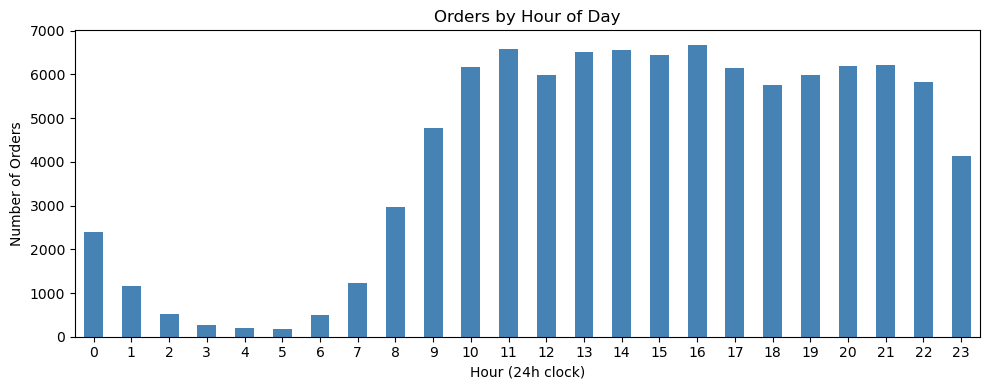

Peak hour: 16 :00


In [36]:
hourly = master.groupby("purchase_hour").size()

hourly.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Orders by Hour of Day")
plt.xlabel("Hour (24h clock)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Peak hour:", hourly.idxmax(), ":00")

## Phase 4 — Key Insights

Summarise what you found. Fill in the numbers after running the cells above.

In [37]:
print("===== OLIST — KEY BUSINESS INSIGHTS =====")
print()

top_cat  = master.groupby("product_category_name_english")["order_id"].count().idxmax()
top_pay  = master["payment_type"].value_counts().index[0]
late_pct = delivered["is_late"].mean() * 100
peak_hr  = master.groupby("purchase_hour").size().idxmax()
on_avg   = delivered[~delivered["is_late"]]["review_score"].mean()
late_avg = delivered[delivered["is_late"]]["review_score"].mean()

print(f"1. Top category    : {top_cat}")
print(f"2. Preferred payment: {top_pay}")
print(f"3. Late delivery rate: {late_pct:.1f}%")
print(f"4. Late orders score {late_avg:.2f} vs {on_avg:.2f} for on-time orders")
print(f"5. Peak shopping hour: {peak_hr}:00")

===== OLIST — KEY BUSINESS INSIGHTS =====

1. Top category    : bed_bath_table
2. Preferred payment: credit_card
3. Late delivery rate: 6.8%
4. Late orders score 2.27 vs 4.29 for on-time orders
5. Peak shopping hour: 16:00
